Regiones y fronteras

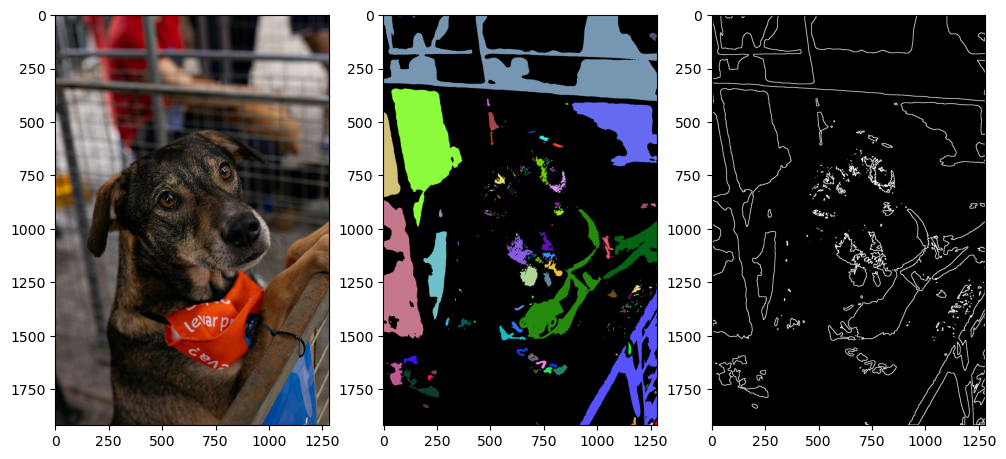

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('perro.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# combinamos tecnicas para preparas la imagen
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#encontramos las regiones
num_l, label = cv2.connectedComponents(binary)
#identificamos por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
color[0] = [0, 0, 0]
colorear = color[label]

#encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(132)
plt.imshow(colorear)
plt.subplot(133)
plt.imshow(contornos_fin, cmap='gray')
plt.show()

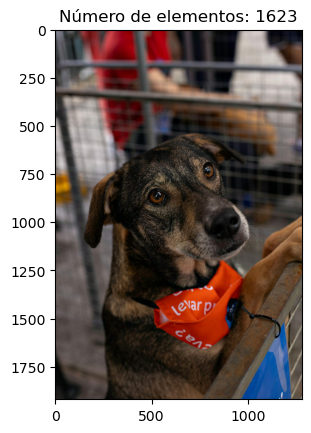

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    e_img = measure.label(binary, connectivity=2) # 2=conectividad es 4 1 = con 
    num_obj = np.max(e_img)
    return num_obj
imagen = cv2.imread('perro.jpg')
conteo = contar_elementos(imagen)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f'Número de elementos: {conteo}')
plt.show()


--- ELEMENTOS POR COLOR (Regiones) ---
Región 1 (Color RGB [ 30  21 155]): 217318.0 píxeles
Región 2 (Color RGB [ 49  99 153]): 599.0 píxeles
Región 3 (Color RGB [215  67  72]): 213.0 píxeles
Región 4 (Color RGB [ 20 219  19]): 875.0 píxeles
Región 5 (Color RGB [191  72  21]): 104881.0 píxeles
Región 6 (Color RGB [130  62 153]): 291.0 píxeles
Región 7 (Color RGB [ 53 100 182]): 320.0 píxeles
Región 8 (Color RGB [214  80  49]): 62233.0 píxeles
Región 9 (Color RGB [25 40 69]): 100.0 píxeles
Región 10 (Color RGB [125 101 190]): 20308.0 píxeles
Región 11 (Color RGB [177 216  45]): 2359.0 píxeles
Región 12 (Color RGB [  4 252 178]): 27.0 píxeles
Región 13 (Color RGB [211 182 178]): 48.0 píxeles
Región 14 (Color RGB [ 4 75 81]): 242.0 píxeles
Región 15 (Color RGB [128  41  14]): 495.0 píxeles
Región 16 (Color RGB [208  32 134]): 12.0 píxeles
Región 17 (Color RGB [247  74 165]): 637.0 píxeles
Región 18 (Color RGB [113  17  58]): 27.0 píxeles
Región 19 (Color RGB [122 220  65]): 519.0 píxeles


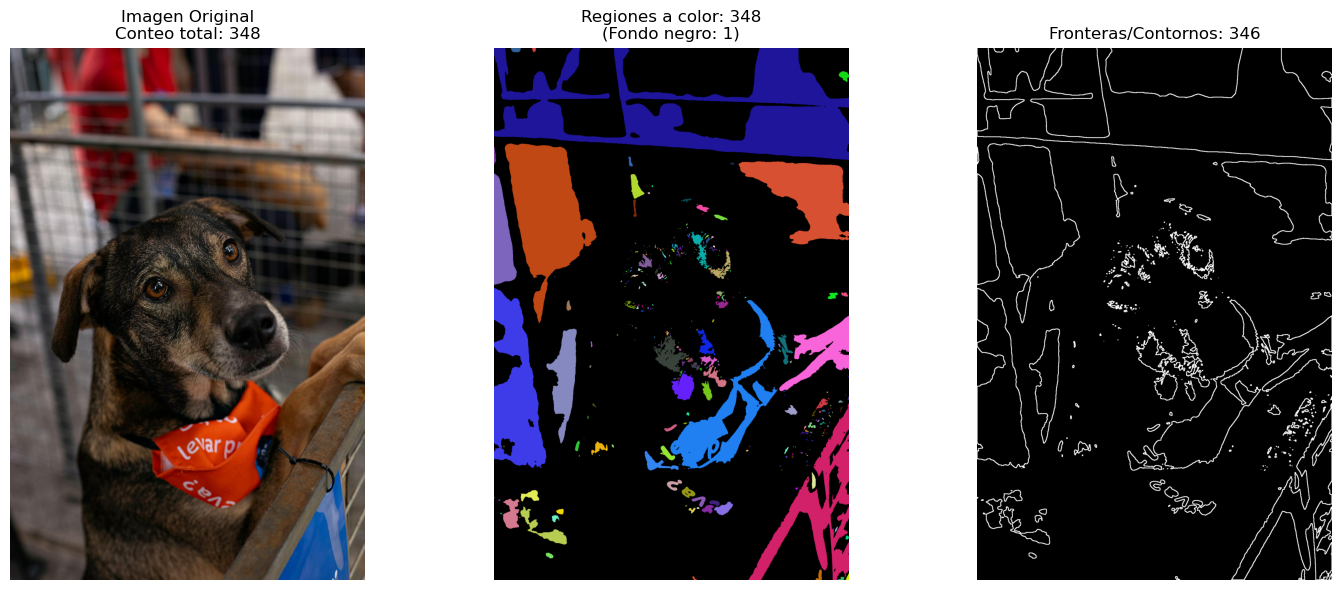

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('perro.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

label_img = measure.label(binary, connectivity=2)
num_elementos = np.max(label_img)

color = np.random.randint(0, 255, size=(num_elementos + 1, 3), dtype=np.uint8)
color[0] = [0, 0, 0]
colorear = color[label_img]

print("--- ELEMENTOS POR COLOR (Regiones) ---")
propiedades = measure.regionprops(label_img)
for prop in propiedades:
    i = prop.label
    area_pixeles = prop.area
    print(f"Región {i} (Color RGB {color[i]}): {area_pixeles} píxeles")

contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
num_fronteras = len(contornos)
contornos_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

print("\n--- ELEMENTOS POR FRONTERA (Contornos) ---")
for i, contorno in enumerate(contornos):
    puntos_frontera = len(contorno)
    print(f"Frontera {i+1}: {puntos_frontera} puntos de contorno")

plt.figure(figsize=(15, 6))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Imagen Original\nConteo total: {num_elementos}')
plt.axis('off')

plt.subplot(132)
plt.imshow(colorear)
plt.title(f'Regiones a color: {num_elementos}\n(Fondo negro: 1)')
plt.axis('off')

plt.subplot(133)
plt.imshow(contornos_fin, cmap='gray')
plt.title(f'Fronteras/Contornos: {num_fronteras}')
plt.axis('off')

plt.tight_layout()
plt.show()